<a href="https://colab.research.google.com/github/aswinic-17/Spotify-minorproject/blob/main/Spotify_minorproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving upload_1cc29b48-7982-4cdb-a0c8-c647c3cd2aa1.csv to upload_1cc29b48-7982-4cdb-a0c8-c647c3cd2aa1 (1).csv


/tmp/ipykernel_210/4116756261.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='playlist_genre', palette='viridis', order=df['playlist_genre'].value_counts().index)


Recommendations for: I Don't Care (with Justin Bieber) - Loud Luxury Remix
      track_name track_artist playlist_genre  track_popularity
11184    The Box  Roddy Ricch            rap                98
23100    The Box  Roddy Ricch            r&b                98
23109    Circles  Post Malone            r&b                98
21384    The Box  Roddy Ricch            r&b                98
18330    Circles  Post Malone          latin                98
Project output files (CSV and PNGs) have been generated.


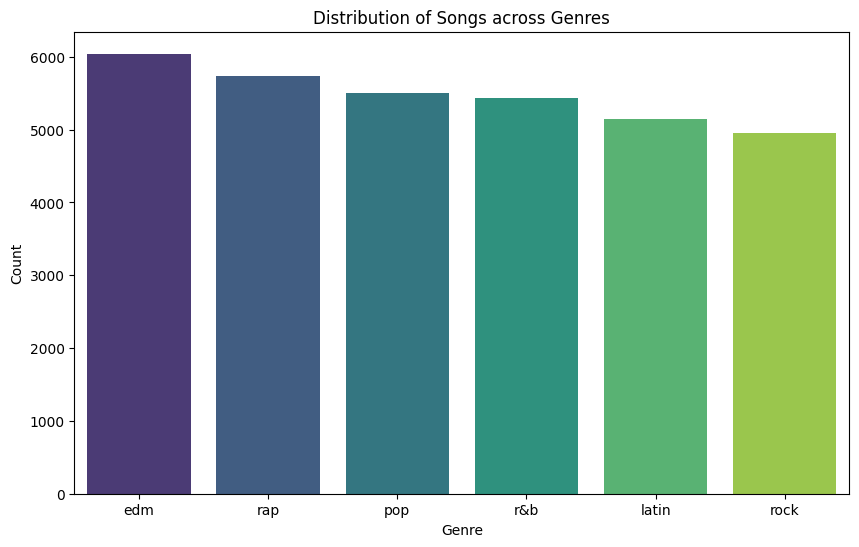

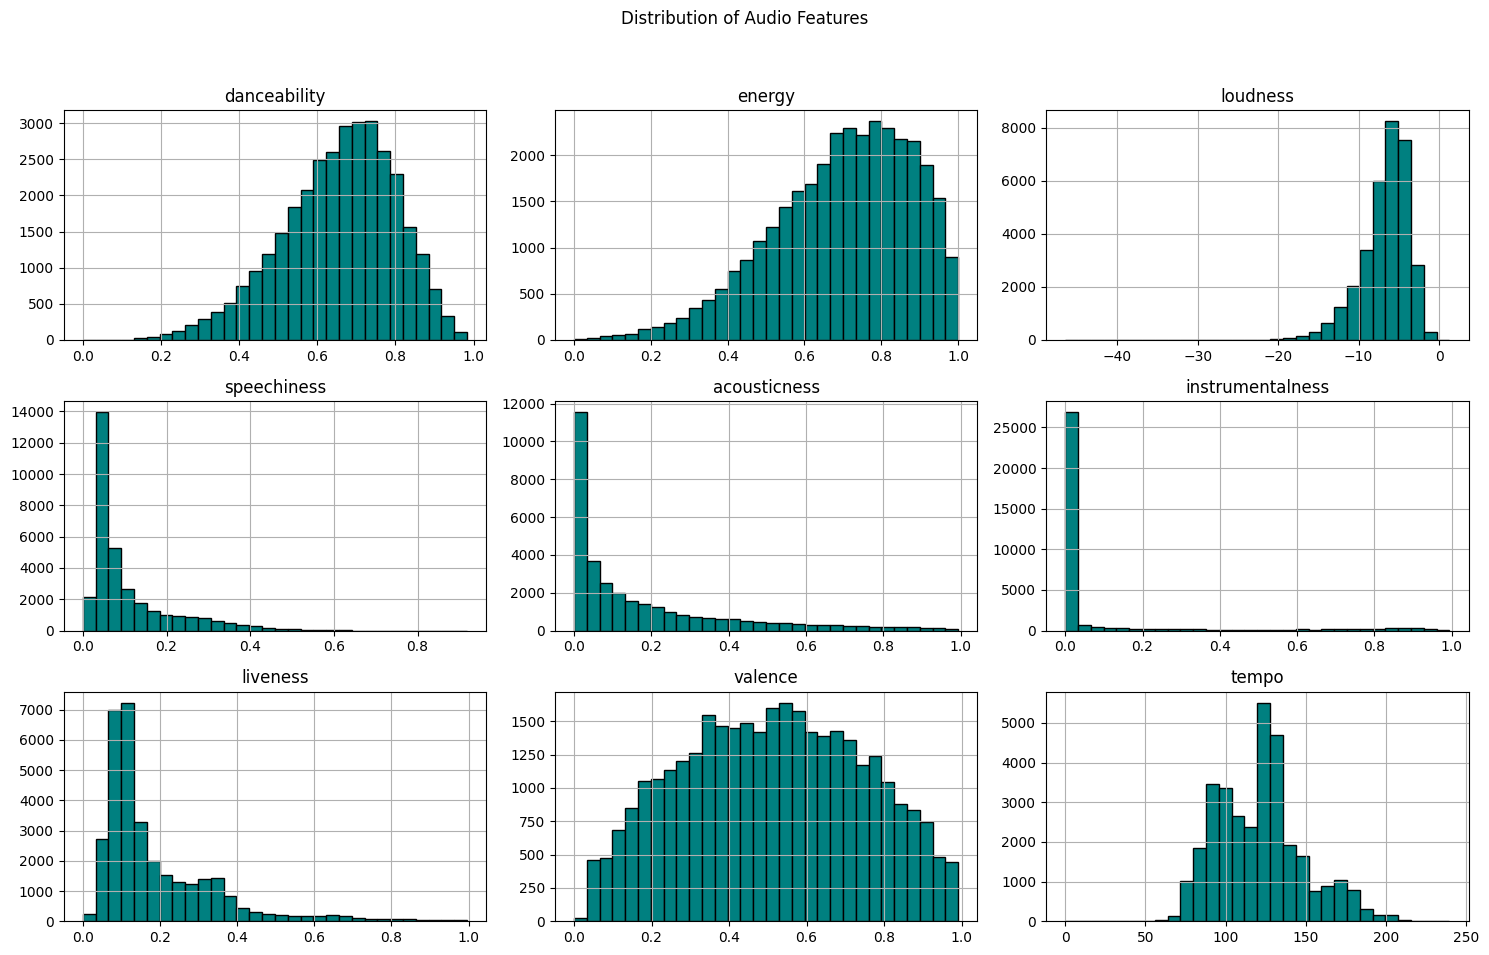

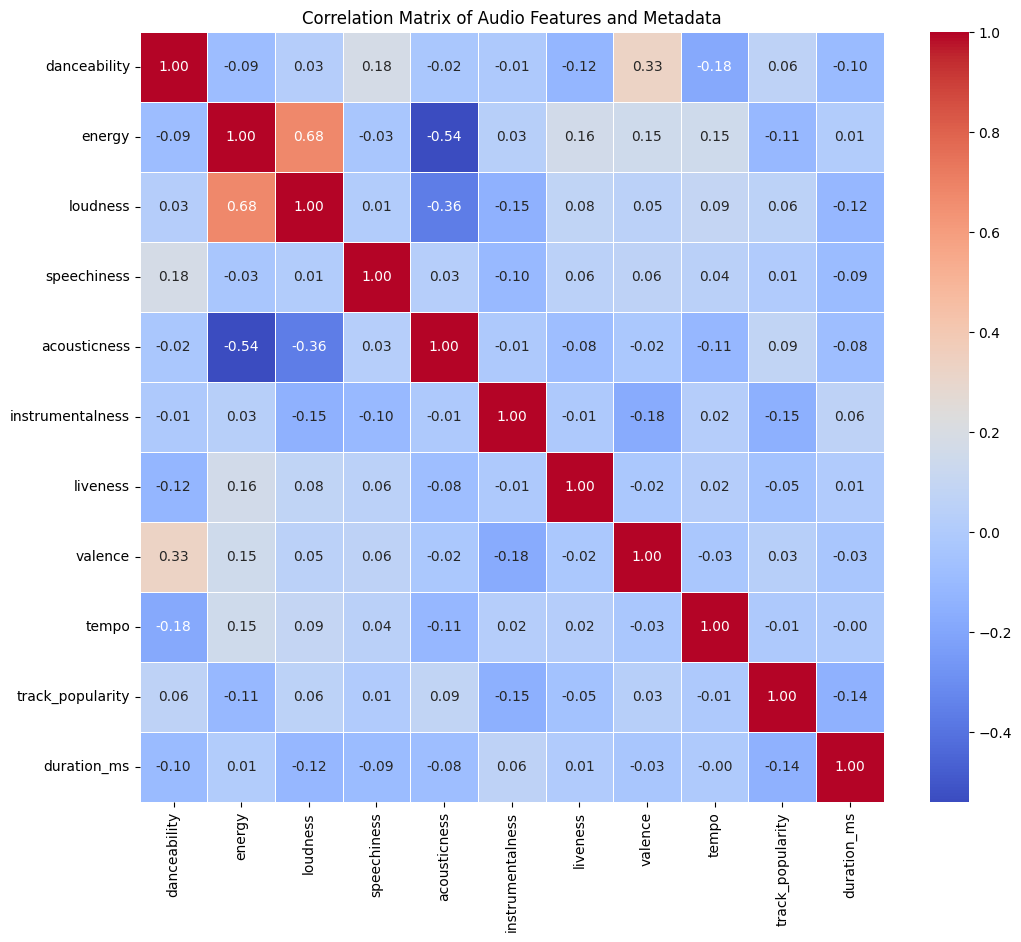

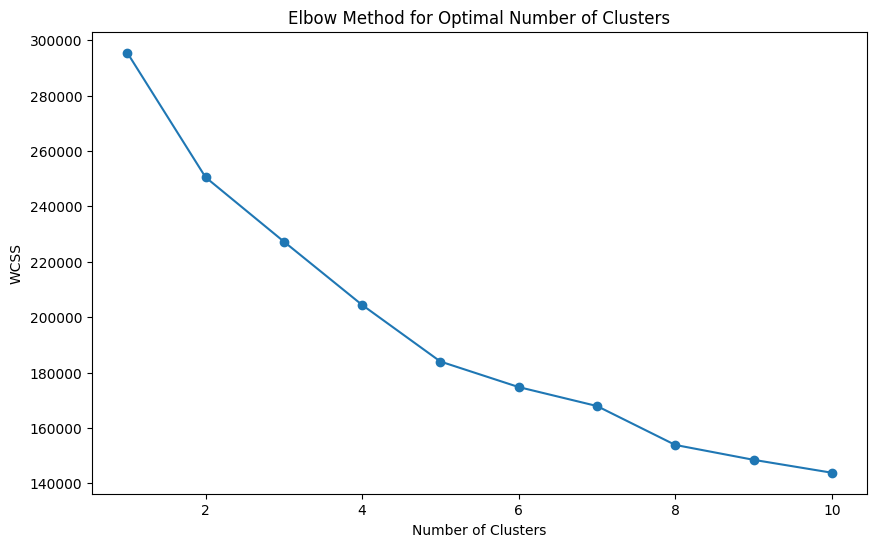

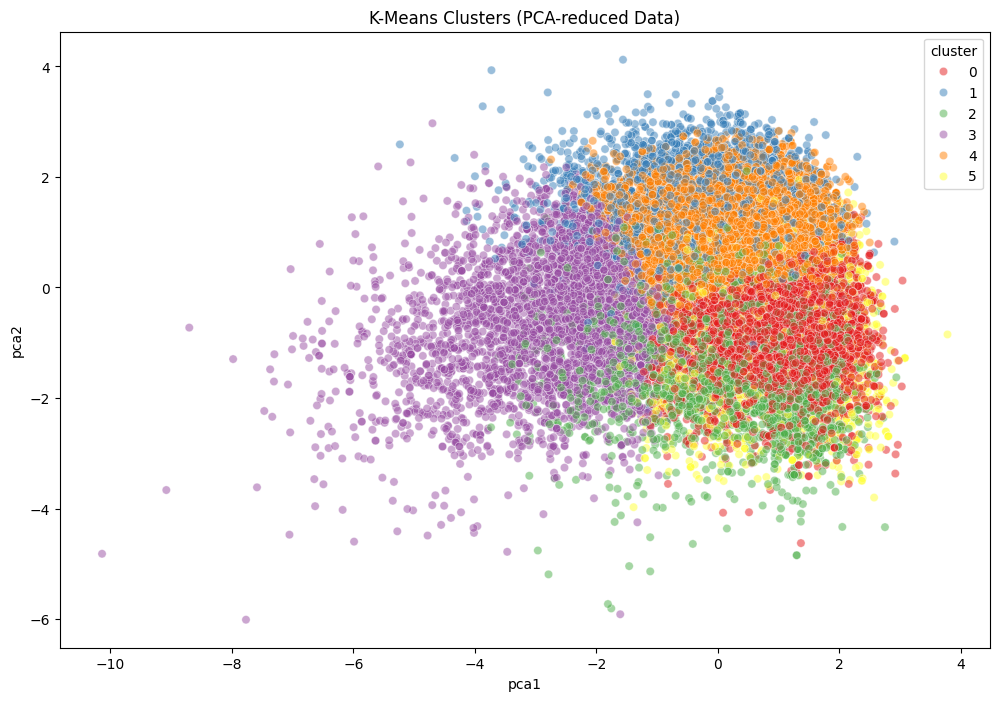

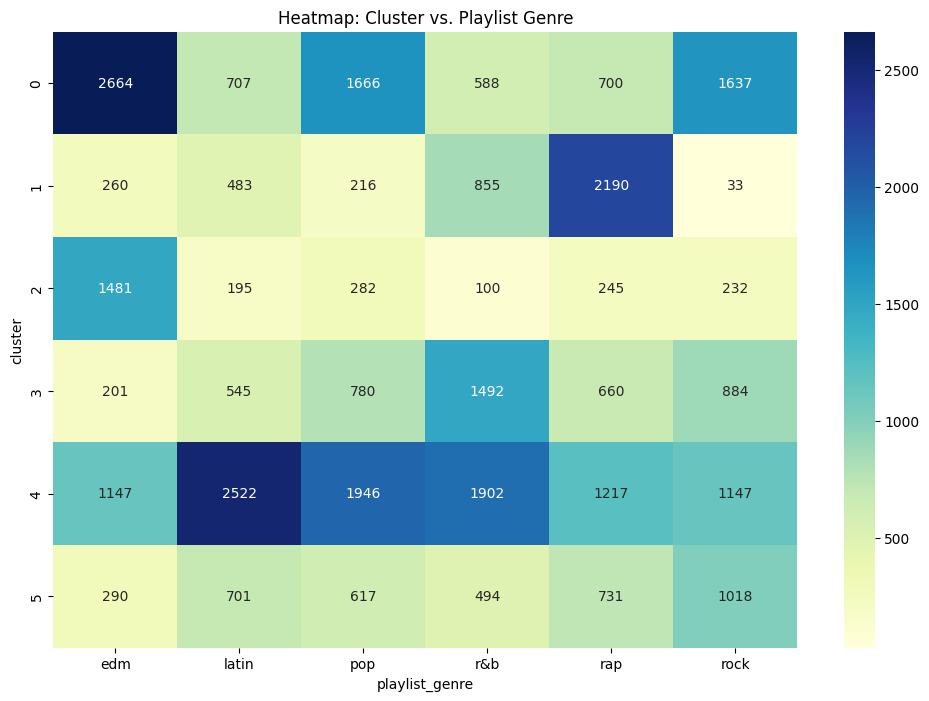

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# 1. Load and Pre-process Data
file_path = 'upload_1cc29b48-7982-4cdb-a0c8-c647c3cd2aa1.csv'
df = pd.read_csv(file_path)
df.dropna(inplace=True)
audio_features = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo'
]

# 2. Data Analysis & Visualization (EDA)
# A. Distribution of Playlist Genres
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='playlist_genre', palette='viridis', order=df['playlist_genre'].value_counts().index)
plt.title('Distribution of Songs across Genres')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.savefig('genre_distribution.png')

# B. Histograms of Audio Features
df[audio_features].hist(bins=30, figsize=(15, 10), layout=(3, 3), color='teal', edgecolor='black')
plt.suptitle('Distribution of Audio Features')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('audio_features_histograms.png')

# 3. Correlation Matrix
plt.figure(figsize=(12, 10))
corr_features = audio_features + ['track_popularity', 'duration_ms']
corr_matrix = df[corr_features].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Audio Features and Metadata')
plt.savefig('correlation_matrix.png')

# 4. Clustering (K-Means)
# Scaling the data (crucial for K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[audio_features])

# A. Elbow Method to find optimal clusters
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.savefig('elbow_method.png')

# B. Fitting the Model (Choosing 6 clusters based on the 6 main genres)
n_clusters = 6
kmeans = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

# C. Visualize Clusters using PCA (Dimensionality Reduction)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df['pca1'] = X_pca[:, 0]
df['pca2'] = X_pca[:, 1]

plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='pca1', y='pca2', hue='cluster', palette='Set1', alpha=0.5)
plt.title('K-Means Clusters (PCA-reduced Data)')
plt.savefig('kmeans_clusters_pca.png')

# D. Heatmap: Cluster vs. Playlist Genre
cluster_genre_dist = pd.crosstab(df['cluster'], df['playlist_genre'])
plt.figure(figsize=(12, 8))
sns.heatmap(cluster_genre_dist, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Heatmap: Cluster vs. Playlist Genre')
plt.savefig('cluster_genre_heatmap.png')

# 5. Recommendation System Model
def recommend_songs(track_id, dataframe, num_recommendations=5):
    """
    Recommends songs from the same cluster based on popularity.
    """
    # Find the cluster of the input song
    try:
        target_cluster = dataframe[dataframe['track_id'] == track_id]['cluster'].iloc[0]
    except IndexError:
        return "Track ID not found."

    # Filter other songs in the same cluster
    recommendations = dataframe[
        (dataframe['cluster'] == target_cluster) &
        (dataframe['track_id'] != track_id)
    ]

    # Sort by popularity and return top results
    return recommendations[['track_name', 'track_artist', 'playlist_genre', 'track_popularity']]\
           .sort_values(by='track_popularity', ascending=False)\
           .head(num_recommendations)

# Example Usage:
example_id = df.iloc[0]['track_id']
example_name = df.iloc[0]['track_name']
print(f"Recommendations for: {example_name}")
print(recommend_songs(example_id, df))

# 6. Export Results
df.to_csv('spotify_songs_with_clusters.csv', index=False)
print("Project output files (CSV and PNGs) have been generated.")